In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [41]:


pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("data/equinoxe_listings.csv",skipinitialspace=True)
leases     = pd.read_csv("data/equinoxe_lease_history.csv",skipinitialspace=True)
concessions= pd.read_csv("data/equinoxe_concessions.csv",skipinitialspace=True)
asking     = pd.read_csv("data/equinoxe_asking_history.csv",skipinitialspace=True)

for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

listings      1,061 lignes   29 colonnes
leases        4,302 lignes   35 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   14 colonnes


In [42]:
# Nettoyage des espaces cachés dans le nom des colonnes
listings.columns = listings.columns.str.strip()
leases.columns = leases.columns.str.strip()
concessions.columns = concessions.columns.str.strip()
asking.columns = asking.columns.str.strip()


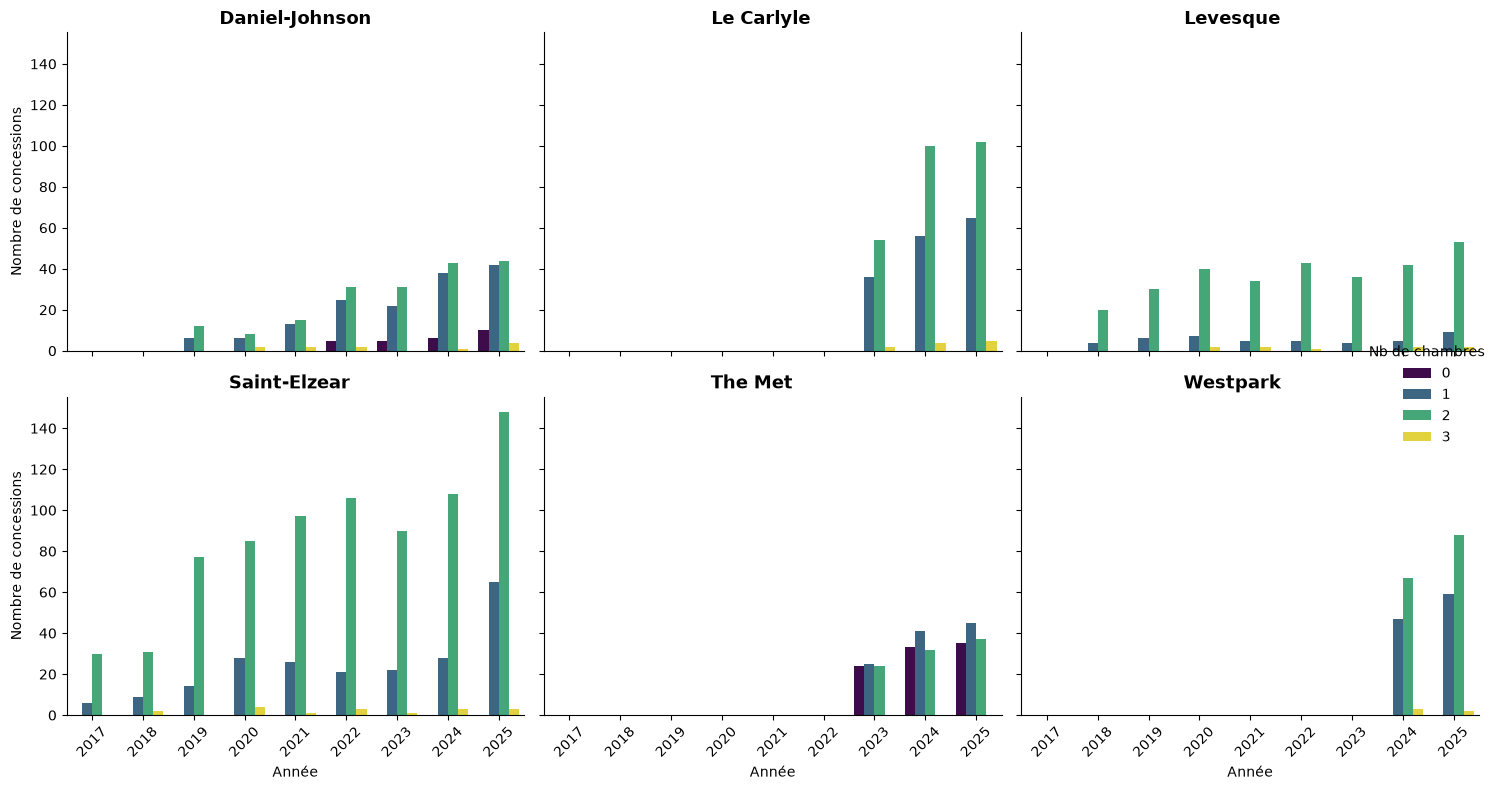

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On s'assure que la colonne est lue comme une date, puis on extrait l'année
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"], errors="coerce")
leases["year"] = leases["sLeaseFrom"].dt.year

# 2. Le reste de votre code reste identique...
data_conc = (leases.groupby(["sBuilding", "year", "sBeds"])["sConcession"])


# 1. On prépare les données : on groupe par Immeuble, Année et Chambres, puis on somme les concessions
data_conc = (leases.groupby(["sBuilding", "year", "sBeds"])["sConcession"]
             .sum()
             .reset_index())

# 2. On demande à Seaborn de croiser tout ça :
# - x : Les années
# - y : Le nombre de concessions
# - hue (couleur) : Le nombre de chambres
# - col (colonnes) : Un graphique par immeuble
g = sns.catplot(
    data=data_conc, 
    kind="bar",
    x="year", 
    y="sConcession", 
    hue="sBeds", 
    col="sBuilding", 
    col_wrap=3,        # Affiche 3 immeubles par ligne
    height=4,          # Hauteur de chaque petit graphique
    aspect=1.2,        # Largeur
    palette="viridis"  # Palette de couleurs
)

# 3. On rend les titres jolis
g.set_axis_labels("Année", "Nombre de concessions")
g.set_titles("{col_name}", size=13, weight="bold") # Le nom de l'immeuble comme titre
g.legend.set_title("Nb de chambres")

# Incliner un peu les années pour être sûr qu'elles ne se chevauchent pas
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()


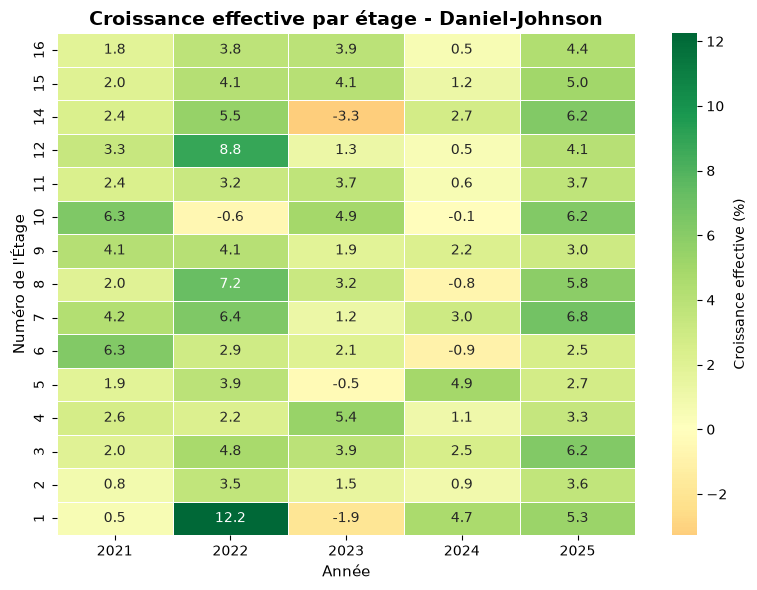

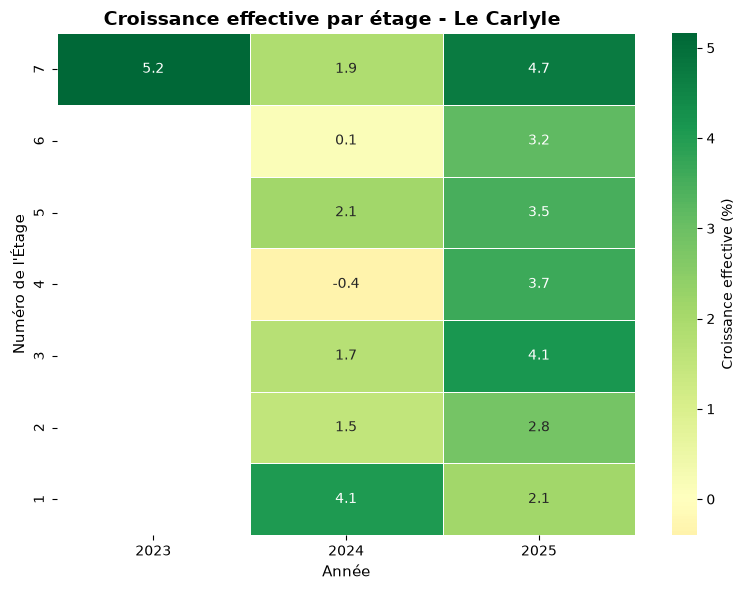

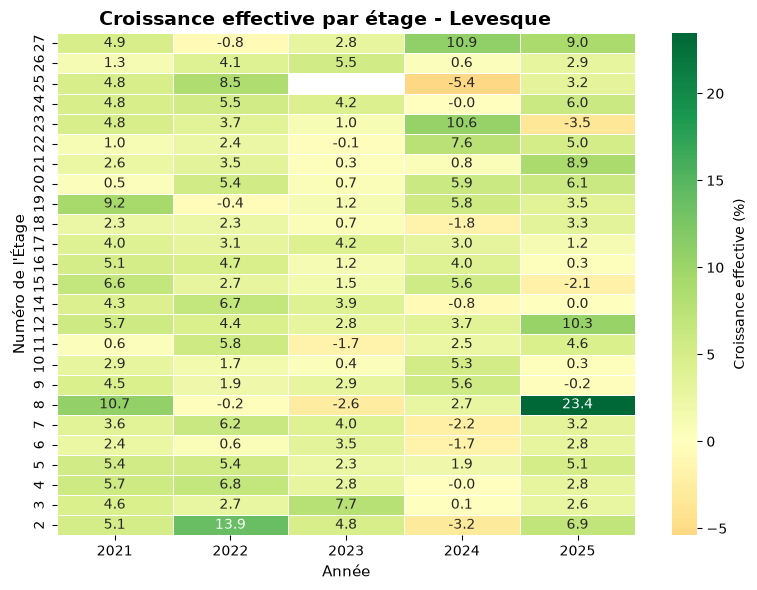

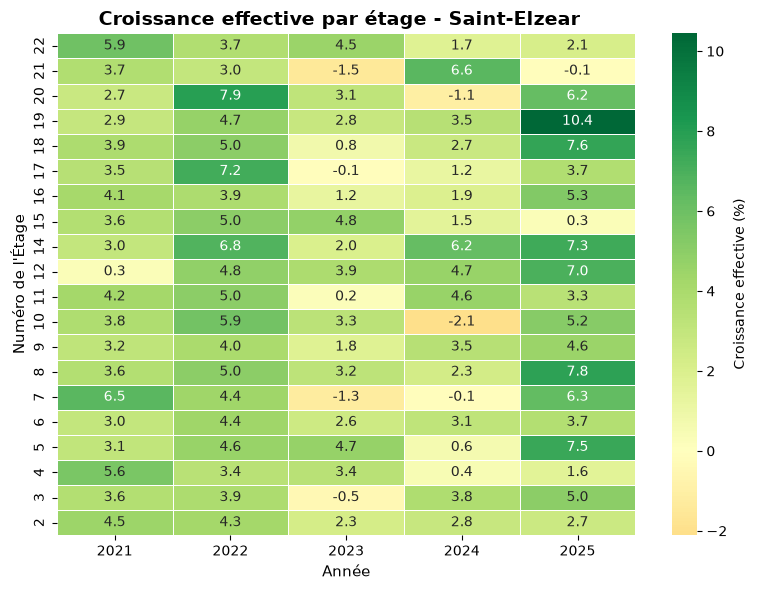

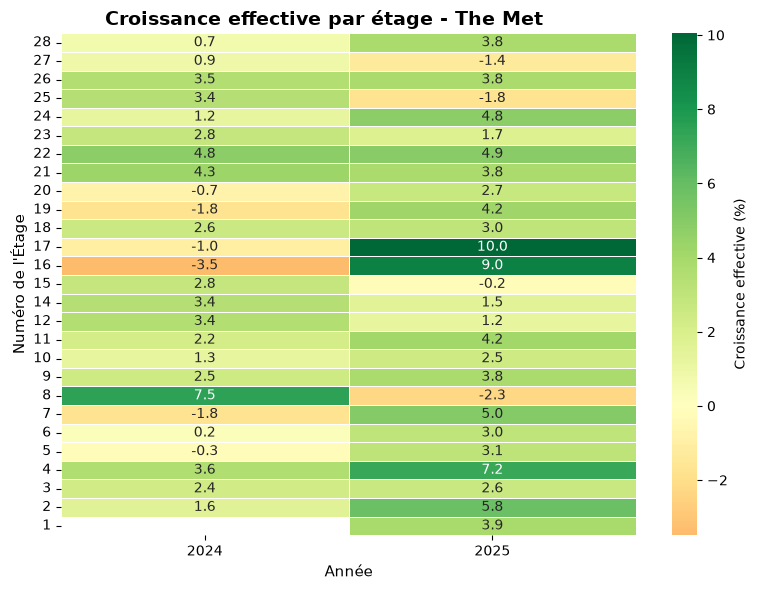

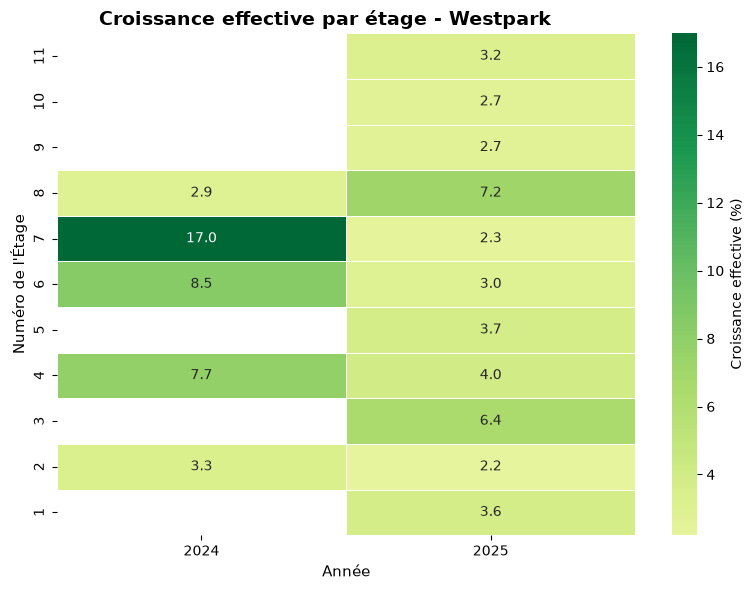

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On s'assure que la colonne est lue comme une date, puis on extrait l'année
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"], errors="coerce")
leases["year"] = leases["sLeaseFrom"].dt.year

# 2. Le reste de votre code reste identique...
data_conc = (leases.groupby(["sBuilding", "year", "sBeds"])["sConcession"])


# 1. On prépare les données : on groupe par Immeuble, Année et Chambres, puis on somme les concessions
data_conc = (leases.groupby(["sBuilding", "year", "sBeds"])["sConcession"]
             .sum()
             .reset_index())

# On s'assure d'avoir notre résumé des données
growth_summary = (pairs_eff[pairs_eff.year.between(2021, 2025)]
                  .groupby(["sBuilding", "sFloor", "year"])["growth_pct"]
                  .mean()
                  .reset_index())

# Liste des immeubles uniques
immeubles = growth_summary["sBuilding"].unique()

for building in immeubles:
    # On isole les données de l'immeuble
    df_b = growth_summary[growth_summary.sBuilding == building]
    if df_b.empty: continue
        
    # On crée une grille spécifiquement pour la heatmap
    pivot_b = df_b.pivot(index="sFloor", columns="year", values="growth_pct")
    
    # On trie pour que les étages les plus élevés soient en haut (comme un vrai bâtiment)
    pivot_b = pivot_b.sort_index(ascending=False)
    
    # Création du graphique
    plt.figure(figsize=(8, 6))
    
    # RdYlGn = Palette Rouge-Jaune-Vert. center=0 permet que le jaune soit à 0%.
    # annot=True écrit le chiffre dans la case
    sns.heatmap(pivot_b, annot=True, fmt=".1f", cmap="RdYlGn", center=0, 
                cbar_kws={'label': 'Croissance effective (%)'}, linewidths=0.5)
    
    plt.title(f"Croissance effective par étage - {building}", fontsize=14, weight="bold")
    plt.ylabel("Numéro de l'Étage", fontsize=11)
    plt.xlabel("Année", fontsize=11)
    
    plt.tight_layout()
    plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On s'assure d'avoir nos calculs de croissance effective
pairs_eff = same_unit_growth(leases, price_col="sRentEffective")

# 2. On groupe par Immeuble et par Superficie (sSqft) pour avoir la croissance moyenne
growth_sqft = (pairs_eff.groupby(["sBuilding", "sSqft"])["growth_pct"]
               .mean()
               .reset_index())

# 3. Création du graphique : Nuage de points avec courbe de régression linéaire (lmplot)
g = sns.lmplot(
    data=growth_sqft,
    x="sSqft",
    y="growth_pct",
    col="sBuilding",
    col_wrap=3,        # 3 immeubles par ligne
    hue="sBuilding",   # Une couleur par immeuble
    height=4,
    aspect=1.2,
    scatter_kws={'alpha': 0.7, 's': 50}, # Transparence et taille des points
    facet_kws={'sharex': False} # Laisse l'axe X s'adapter car les immeubles n'ont pas les mêmes tailles d'appartements
)

# 4. Mise en forme
g.set_axis_labels("Superficie (Pieds carrés)", "Croissance effective moyenne (%)")
g.set_titles("{col_name}", size=13, weight="bold")

plt.tight_layout()
plt.show()


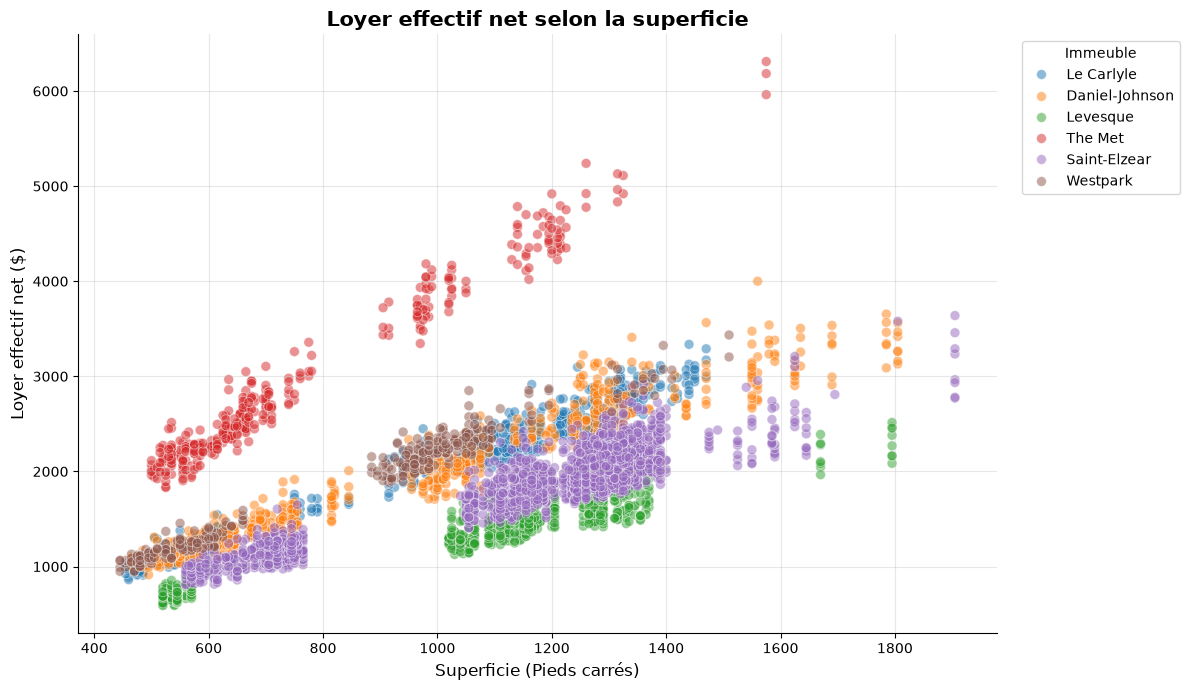

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Création du nuage de points
sns.scatterplot(
    data=leases,
    x="sSqft",
    y="sRentEffective",
    hue="sBuilding",   # Une couleur par immeuble
    alpha=0.5,         # Points semi-transparents pour voir les accumulations
    s=50,              # Taille des points
    palette="tab10"
)

# Mise en forme du graphique
plt.title("Loyer effectif net selon la superficie", fontsize=15, fontweight="bold")
plt.xlabel("Superficie (Pieds carrés)", fontsize=12)
plt.ylabel("Loyer effectif net ($)", fontsize=12)

# Déplacer la légende pour ne pas cacher les données
plt.legend(title="Immeuble", bbox_to_anchor=(1.02, 1), loc='upper left')

# Esthétique
plt.grid(alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


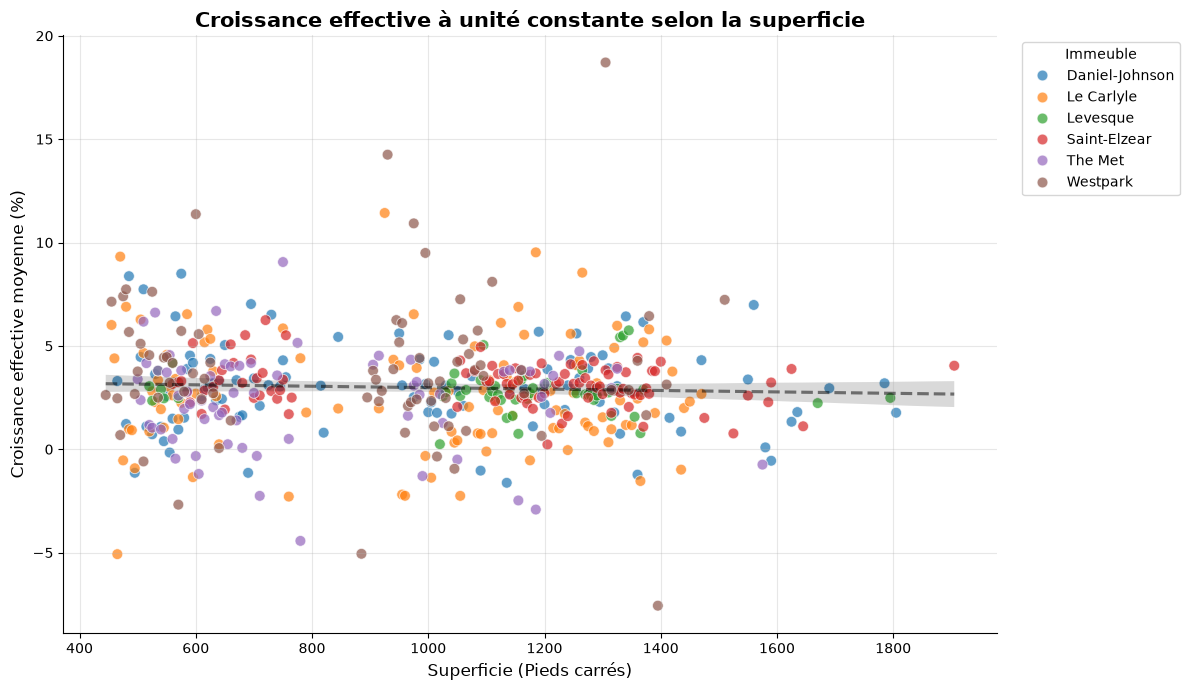

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On s'assure d'avoir les données de croissance effective
pairs_eff = same_unit_growth(leases, price_col="sRentEffective")

# 2. On groupe par Immeuble et Superficie pour avoir la moyenne
growth_sqft = (pairs_eff.groupby(["sBuilding", "sSqft"])["growth_pct"]
               .mean()
               .reset_index())

plt.figure(figsize=(12, 7))

# 3. Nuage de points global (tous les immeubles ensemble)
sns.scatterplot(
    data=growth_sqft,
    x="sSqft",
    y="growth_pct",
    hue="sBuilding",
    palette="tab10",
    s=60,
    alpha=0.7
)

# 4. Ajout d'une ligne de tendance globale (moyenne de tout le portefeuille)
sns.regplot(
    data=growth_sqft,
    x="sSqft",
    y="growth_pct",
    scatter=False,    # On a déjà dessiné les points juste au-dessus
    color="black",
    line_kws={"linestyle": "--", "alpha": 0.5}
)

# Mise en forme
plt.title("Croissance effective à unité constante selon la superficie", fontsize=15, fontweight="bold")
plt.xlabel("Superficie (Pieds carrés)", fontsize=12)
plt.ylabel("Croissance effective moyenne (%)", fontsize=12)

# Déplacer la légende
plt.legend(title="Immeuble", bbox_to_anchor=(1.02, 1), loc='upper left')

# Esthétique
plt.grid(alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ══════════════════════════════════════════════════════════════════
# 1. CHARGER ET PRÉPARER L'INDICE CPI-LOGEMENT (conjoncture_loyer_qc)
# ══════════════════════════════════════════════════════════════════

# Le fichier a un format "wide" avec séparateur ";" et virgules décimales
cj_raw = pd.read_csv(
    "data/conjoncture_loyer_qc.csv",
    sep=";",
    skiprows=9,       # sauter les 9 lignes d'en-tête
    header=0,
    nrows=15,         # lignes 10 à 26 (les données utiles)
    dtype=str,
    encoding="utf-8"
)

# Garder uniquement la ligne "Logement" (ligne 14 du CSV = indice CPI logement)
cj_raw.columns = cj_raw.columns.str.strip().str.replace('"', '')
logement = cj_raw[cj_raw.iloc[:, 0].str.contains("Logement", na=False)].iloc[0, 1:]

# Extraire les noms de mois depuis l'en-tête (ligne 10 du CSV)
header_line = cj_raw.columns[1:]  # toutes les colonnes sauf la 1ère

# Construire la série temporelle CPI
mois_fr = {
    "janvier": "01", "février": "02", "mars": "03", "avril": "04",
    "mai": "05", "juin": "06", "juillet": "07", "août": "08",
    "septembre": "09", "octobre": "10", "novembre": "11", "décembre": "12"
}

dates_cpi = []
vals_cpi = []
for col, val in zip(header_line, logement):
    col_clean = col.strip().replace('"', '')
    val_clean = str(val).strip().replace('"', '').replace(',', '.')
    if val_clean == '' or val_clean == 'nan':
        continue
    # Extraire mois et année, ex: "avril 2021"
    parts = col_clean.split()
    if len(parts) == 2 and parts[0].lower() in mois_fr:
        m = mois_fr[parts[0].lower()]
        y = parts[1]
        dates_cpi.append(pd.Timestamp(f"{y}-{m}-01"))
        vals_cpi.append(float(val_clean))

df_cpi = pd.DataFrame({"date": dates_cpi, "CPI_Logement": vals_cpi}).set_index("date")

# Calculer la variation annuelle (%) de l'indice CPI-Logement
df_cpi["CPI_Logement_pct_yoy"] = df_cpi["CPI_Logement"].pct_change(12) * 100

print(f"CPI-Logement : {len(df_cpi)} mois, de {df_cpi.index.min():%Y-%m} à {df_cpi.index.max():%Y-%m}")
print(df_cpi.tail())


CPI-Logement : 65 mois, de 2021-04 à 2026-08
            CPI_Logement  CPI_Logement_pct_yoy
date                                          
2026-04-01         190.2              1.765650
2026-05-01         190.1              1.712146
2026-06-01         190.2              1.548318
2026-07-01         190.3              1.277275
2026-08-01         190.9              1.542553


In [66]:
# ══════════════════════════════════════════════════════════════════
# 2. CHARGER ET PRÉPARER LA CMUC (Croissance Moyenne à Unité Constante)
#    depuis equinoxe_lease_history.csv
# ══════════════════════════════════════════════════════════════════

leases = pd.read_csv("data/equinoxe_lease_history.csv", skipinitialspace=True)

# Nettoyage
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"])
leases["sRentEffective"] = pd.to_numeric(leases["sRentEffective"], errors="coerce")

# Identifier chaque unité de façon unique
leases["unit_id"] = leases["sPropCode"].str.strip() + "_" + leases["sUnitCode"].str.strip()

# Trier par unité et séquence de bail
leases = leases.sort_values(["unit_id", "sTermSeq"])

# Calculer la croissance à unité constante :
# Pour chaque unité, variation du loyer effectif entre deux baux successifs
leases["rent_prev"] = leases.groupby("unit_id")["sRentEffective"].shift(1)
leases["cmuc"] = (leases["sRentEffective"] - leases["rent_prev"]) / leases["rent_prev"]

# Exclure la première observation de chaque unité (pas de "précédent")
leases_cmuc = leases.dropna(subset=["cmuc"]).copy()

# Agréger par mois (date de début de bail)
leases_cmuc["mois"] = leases_cmuc["sLeaseFrom"].dt.to_period("M").dt.to_timestamp()

cmuc_monthly = (
    leases_cmuc
    .groupby("mois")["cmuc"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "CMUC_mean", "median": "CMUC_median", "count": "n_baux"})
)

# Convertir en %
cmuc_monthly["CMUC_mean_pct"] = cmuc_monthly["CMUC_mean"] * 100
cmuc_monthly["CMUC_median_pct"] = cmuc_monthly["CMUC_median"] * 100

print(f"CMUC : {len(cmuc_monthly)} mois, de {cmuc_monthly.index.min():%Y-%m} à {cmuc_monthly.index.max():%Y-%m}")
print(cmuc_monthly.tail(10))


CMUC : 98 mois, de 2017-09 à 2025-12
            CMUC_mean  CMUC_median  n_baux  CMUC_mean_pct  CMUC_median_pct
mois                                                                      
2025-03-01   0.033108     0.027789      51       3.310833         2.778906
2025-04-01   0.043237     0.042504      44       4.323705         4.250351
2025-05-01   0.043332     0.037038      76       4.333211         3.703799
2025-06-01   0.039058     0.035235     104       3.905793         3.523460
2025-07-01   0.038997     0.034661      91       3.899662         3.466135
2025-08-01   0.040494     0.041860      77       4.049443         4.186047
2025-09-01   0.037884     0.033944     101       3.788394         3.394435
2025-10-01   0.035233     0.036365      59       3.523332         3.636530
2025-11-01   0.034479     0.036725      57       3.447917         3.672526
2025-12-01   0.038860     0.043732      62       3.886019         4.373198



Période commune : 2021-04 → 2025-12 (57 mois)


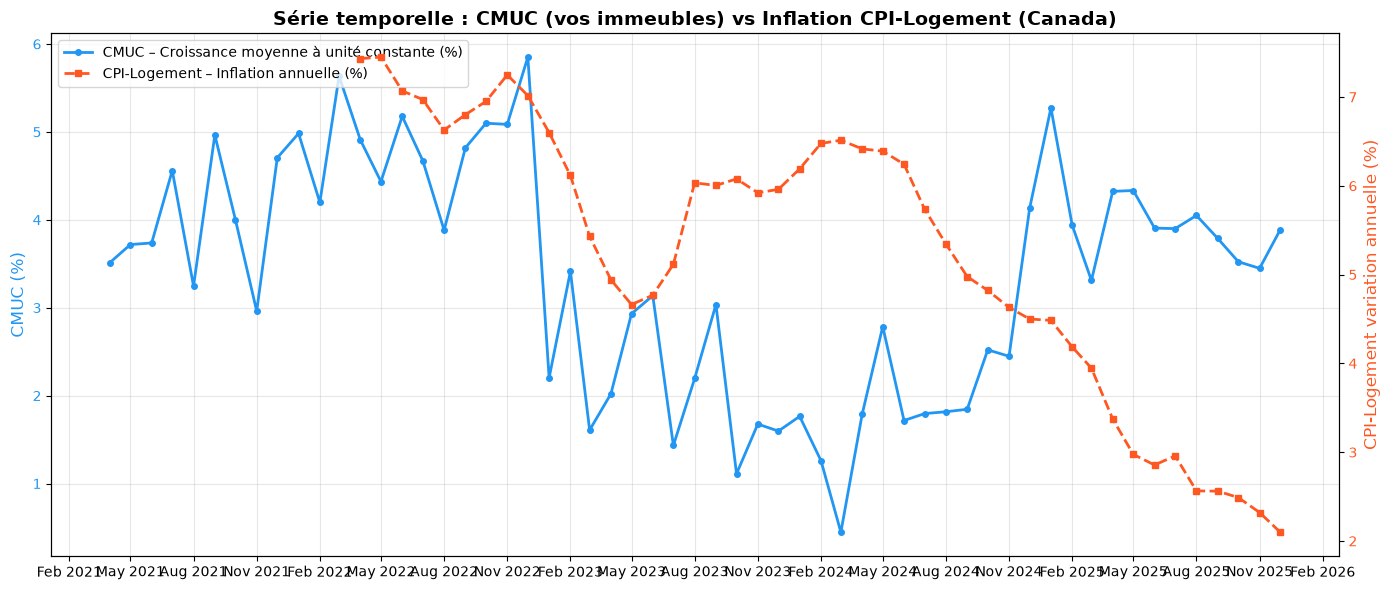

In [67]:
# ══════════════════════════════════════════════════════════════════
# 3. FUSIONNER ET VISUALISER LES DEUX SÉRIES
# ══════════════════════════════════════════════════════════════════

# Fusionner sur la date
df_merged = cmuc_monthly[["CMUC_mean_pct", "n_baux"]].join(
    df_cpi[["CPI_Logement_pct_yoy"]], how="inner"
)

print(f"\nPériode commune : {df_merged.index.min():%Y-%m} → {df_merged.index.max():%Y-%m} ({len(df_merged)} mois)")

# ─── Graphique 1 : Deux axes Y (superposition des tendances) ────
fig, ax1 = plt.subplots(figsize=(14, 6))

color_cmuc = "#2196F3"
color_cpi  = "#FF5722"

# Axe gauche : CMUC
ax1.plot(df_merged.index, df_merged["CMUC_mean_pct"],
         color=color_cmuc, linewidth=2, marker="o", markersize=4,
         label="CMUC – Croissance moyenne à unité constante (%)")
ax1.set_ylabel("CMUC (%)", color=color_cmuc, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_cmuc)
ax1.set_xlabel("")

# Axe droit : CPI-Logement (variation annuelle)
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged["CPI_Logement_pct_yoy"],
         color=color_cpi, linewidth=2, linestyle="--", marker="s", markersize=4,
         label="CPI-Logement – Inflation annuelle (%)")
ax2.set_ylabel("CPI-Logement variation annuelle (%)", color=color_cpi, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_cpi)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.set_title("Série temporelle : CMUC (vos immeubles) vs Inflation CPI-Logement (Canada)",
              fontsize=14, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
fig.tight_layout()
plt.show()


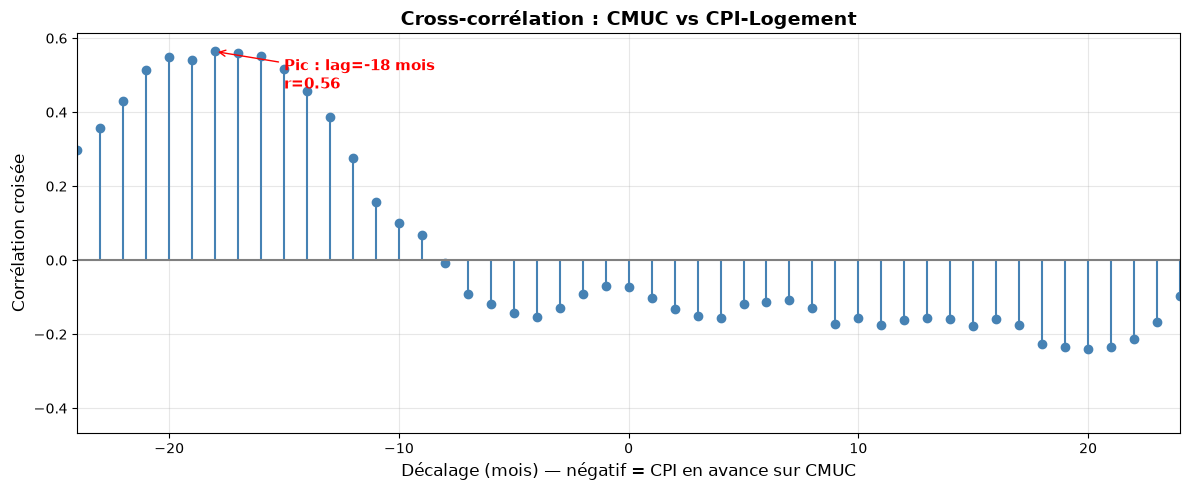


 Corrélation (lag=0) : -0.075
 Meilleur lag        : -18 mois (r = 0.564)


In [68]:
# ─── Graphique 2 : Cross-corrélation (lag analysis) ─────────────
# PAS BESOIN DE SCIPY — on utilise numpy directement

# Normaliser les deux séries (z-score) pour comparer les tendances
s1 = df_merged["CMUC_mean_pct"].dropna()
s2 = df_merged["CPI_Logement_pct_yoy"].dropna()

# Aligner
common = s1.index.intersection(s2.index)
s1 = s1.loc[common]
s2 = s2.loc[common]

if len(common) >= 6:
    s1_norm = (s1 - s1.mean()) / s1.std()
    s2_norm = (s2 - s2.mean()) / s2.std()

    # Cross-corrélation avec numpy uniquement
    corr = np.correlate(s1_norm.values, s2_norm.values, mode="full") / len(s1_norm)
    lags = np.arange(-len(s1_norm) + 1, len(s1_norm))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stem(lags, corr, linefmt="steelblue", markerfmt="o", basefmt="gray")
    ax.set_xlabel("Décalage (mois) — négatif = CPI en avance sur CMUC", fontsize=12)
    ax.set_ylabel("Corrélation croisée", fontsize=12)
    ax.set_title("Cross-corrélation : CMUC vs CPI-Logement", fontsize=14, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-24, 24)

    # Annoter le pic maximum
    best_lag = lags[np.argmax(corr)]
    best_corr = np.max(corr)
    ax.annotate(f"Pic : lag={best_lag} mois\nr={best_corr:.2f}",
                xy=(best_lag, best_corr),
                xytext=(best_lag + 3, best_corr - 0.1),
                arrowprops=dict(arrowstyle="->", color="red"),
                fontsize=11, color="red", fontweight="bold")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Corrélation simple (lag=0)
    print(f"\n Corrélation (lag=0) : {s1.corr(s2):.3f}")
    print(f" Meilleur lag        : {best_lag} mois (r = {best_corr:.3f})")
else:
    print(" Pas assez de données communes pour la cross-corrélation.")


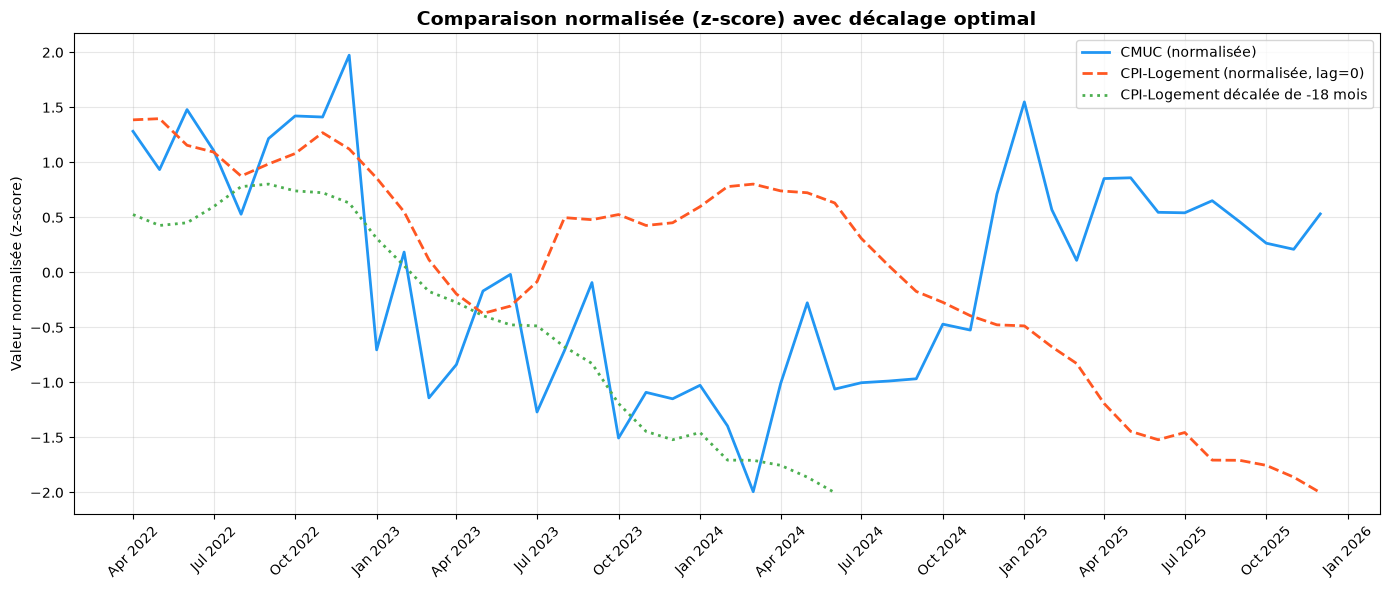

In [69]:
# ─── Graphique 3 : CMUC vs CPI avec décalage optimal ────────────
if len(common) >= 6:
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(s1.index, s1_norm, color=color_cmuc, linewidth=2,
            label="CMUC (normalisée)")
    ax.plot(s2.index, s2_norm, color=color_cpi, linewidth=2,
            linestyle="--", label="CPI-Logement (normalisée, lag=0)")

    # Décaler CPI du meilleur lag
    if best_lag != 0:
        s2_shifted = s2_norm.shift(best_lag)
        ax.plot(s2_shifted.index, s2_shifted, color="#4CAF50", linewidth=2,
                linestyle=":", label=f"CPI-Logement décalée de {best_lag} mois")

    ax.set_title("Comparaison normalisée (z-score) avec décalage optimal",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Valeur normalisée (z-score)")
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


Points à noter pour les simplifications de notre modèle

La faible influence du numéro d'étage du loyer sur la croissance effective à unité constante des loyers.

Nous voyons que très peu de corrélation entre la croissance effective et le numéro d'étage dans lequel se retrouve l'unité. Il n'y a que certains étages dans certains étages dans certains immeubles où nous pouvons voir une certaine incertitude quant à la croissance effective à unité constante des loyers. Plus particulièrement, la dernière étage de l'immeuble Met, où se retrouve les penthouses, est plus sensible aux changements drastiques. Elle comporte des données aberrantes qui sont négligeables dans notre modèle puisque nous regardons en fin de compte la médiane.

La croissance linéaire du prix des unités selon la superficie.

Nous pensions peut-être que le prix des unités selon la superficie ne grandissait pas selon un modèle linéaire. En effet, il était intuitif que plus la superficie de l'unité est grande, plus le prix du loyer est élevé. Toutefois, nous ne savions pas quelle était l'ordre de grandeur (logarithmique, linéaire, exponentielle). Nous croyions que l'ordre était exponentielle, que les clients devraient payer beaucoup plus cher pour avoir un peu plus grand. Toutefois, en regardant les prix des unités selon la superficie, nous voyons clairement que le prix des unités grandit linéairement avec la superficie de cette dernière.

Le prix des loyers est influencé par la conjoncture économique canadienne

Nous voulions regarder si les prix des loyers est influencé par la conjoncture économique canadienne. Nous avons donc comparer la croissance des effective à unité constante avec la variation du IPC des logements à l'aide d'une série temporelle. Nous avons une corrélation entre ces deux séries. En effet, nous voyons que les prix des loyers varient 18 suivants la variation de l'IPC des logements. Ce point est justifiable de plusieurs manières.

Premièrement, les locataires signent leurs bails généralement pour une durée d'au moins un an. C'est pour cette raison que les augmentations de loyer réagissent beaucoup plus tard à la conjecture économique, puisque les augmentations se produisent seulement au moment où le bail échoue.

Deuxièmement, le marché locatif est généralement plus lent. En effet, les propriétaires ajustent les loyers en fonction de la demande observée dans les derniers mois, et non seulement les dernières semaines. Ils veulent remarquer une réelle tendance avant de changer leurs prix.

Troisièmement, certaines politiques de régulation pour le Québec et l'Ontario peuvent retarder les hausses de loyers. Ce qui fait en sorte que les locataires reçoivent la hausse des loyers plus tard.

Dernièrement, la conjoncture économique bouge toujours, tandis que certains agents peuvent prendre beaucoup de temps à réagir. En effet, les actions du gouvernement avec leurs investissements ainsi que leurs bilans financiers ou la banque du Canada avec le réajustement des taux d'intéret peuvent faire changer le prix des loyers. Toutefois, leurs actions prennent du temps. Effectivement, le budget du gouvernement est annuel et les rapports de la banque du Canada sont trimestrielles.